In [1]:
import math

import numpy as np
import numba
import numba.cuda as cuda
import matplotlib.pyplot as plt

from CRU import CRUs, RyR_stationary, LCC_stationary
from params import RestrepoParams
#from currents import get_ICa
from cpu import *

In [2]:
@numba.njit
def renormalise(arr, window_length):
    rn_len = arr.shape[0] // window_length
    out = np.zeros(rn_len)
    for i in range(rn_len):
        out[i] = arr[i*window_length:(i+1)*window_length].mean()
    return out

In [3]:
nb_cru = RestrepoCPU()

In [4]:
nb_cru.forward(1e-3, 20_000_000, 100)

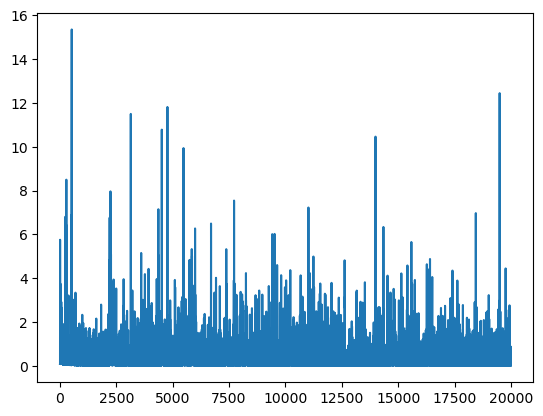

In [5]:
plt.plot(nb_cru.t, nb_cru.cp)
plt.show()

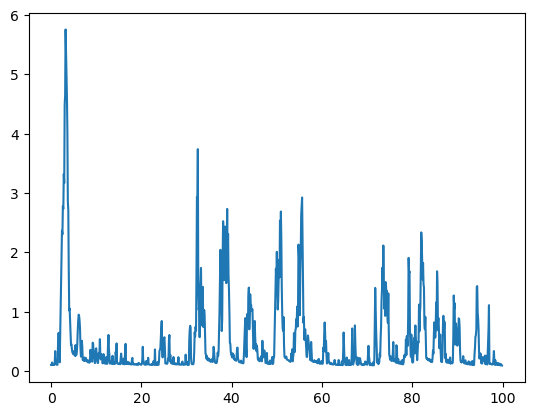

In [6]:
plt.plot(nb_cru.t[:1000], nb_cru.cp[:1000])
plt.show()

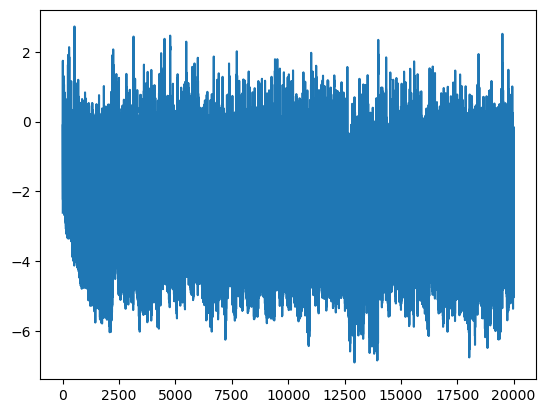

In [9]:
plt.plot(nb_cru.t, np.log(nb_cru.cp-nb_cru.cp.min()+1e-3))
plt.show()

In [10]:
log_process = np.log(nb_cru.cp-nb_cru.cp.min()+1e-3)

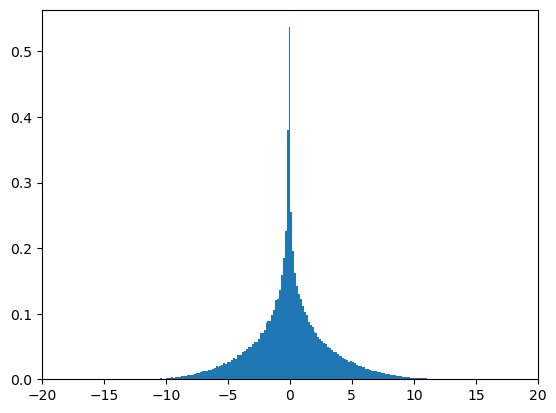

In [11]:
plt.hist((log_process[1:] - log_process[:-1]) / np.sqrt(0.1), bins=200, density=True)
plt.xlim(-20,20)
plt.show()

In [47]:
cp_rn = renormalise(nb_cru.cp, 50)

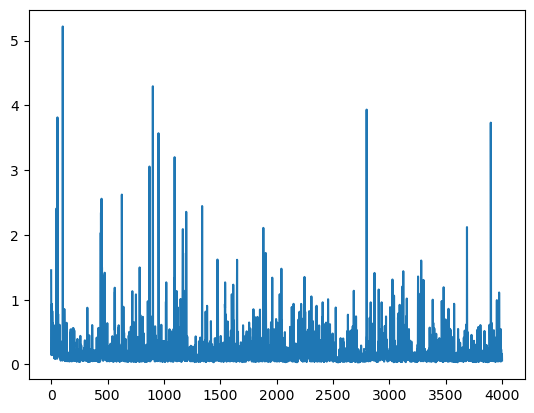

In [48]:
plt.plot(cp_rn)
plt.show()

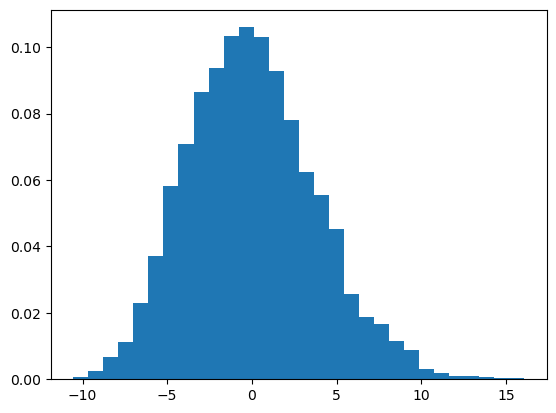

In [49]:
log_process = np.log(cp_rn-cp_rn.min()+1e-3)
plt.hist((log_process[1:] - log_process[:-1]) / np.sqrt(0.1), bins=30, density=True)
plt.show()

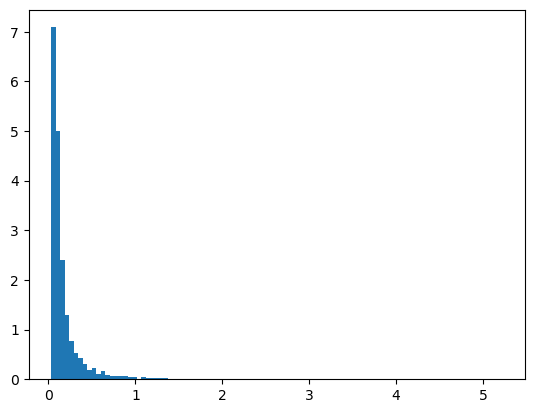

In [50]:
plt.hist(cp_rn, bins=100, density=True)
plt.show()

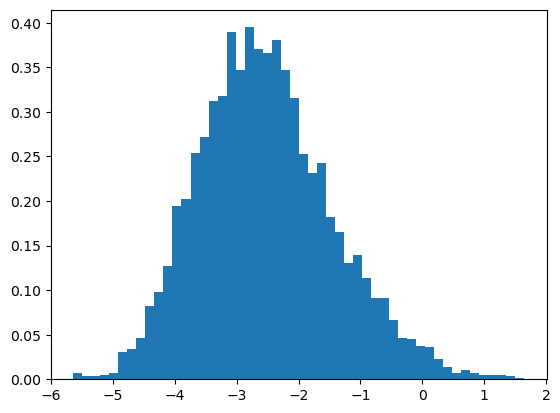

In [51]:
log_cs_shifted = np.log(np.sort(cp_rn)[5:] - cp_rn.min())
plt.hist(log_cs_shifted, bins=50, density=True)
plt.show()

In [52]:
def ccdf(arr: npt.NDArray):
    ps = np.arange(1, len(arr)+1) / len(arr)
    vals = np.sort(arr)[::-1]
    return ps, vals

In [53]:
m = np.log(np.sort(cp_rn)[1:] - cp_rn.min()).mean()
s = np.log(np.sort(cp_rn)[1:] - cp_rn.min()).std()
log_normals = np.exp(m + s * np.random.normal(size=10_000))

In [54]:
ps, bins = ccdf(np.sort(cp_rn)[1:-1] - cp_rn.min())
ln_ps, ln_bins = ccdf(log_normals)

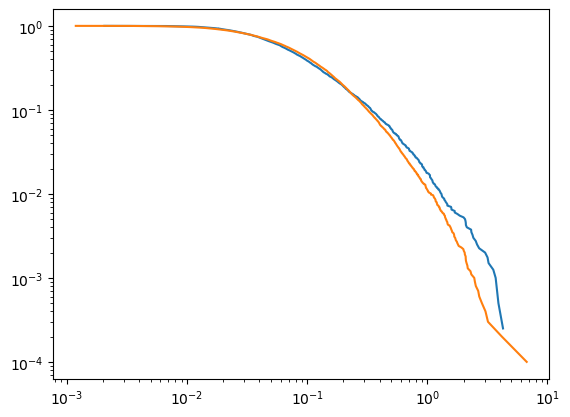

In [55]:
plt.plot(bins, ps)
plt.plot(ln_bins, ln_ps)
plt.xscale('log')
plt.yscale('log')
plt.show()

In [56]:
shift = cp_rn.mean()
x = cp_rn - shift
acf = np.correlate(x, x, mode='full')
acf = acf / np.dot(x, x)

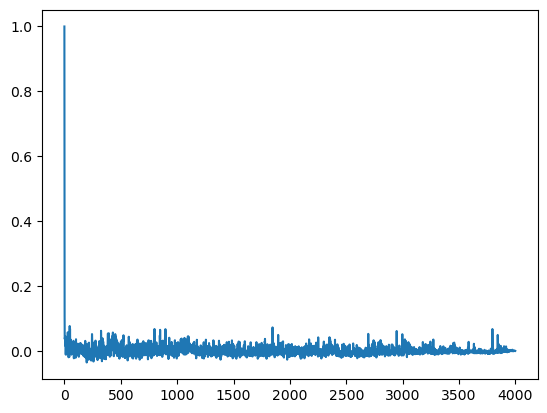

In [57]:
middle = len(acf)//2
plt.plot(acf[middle:])
plt.show()

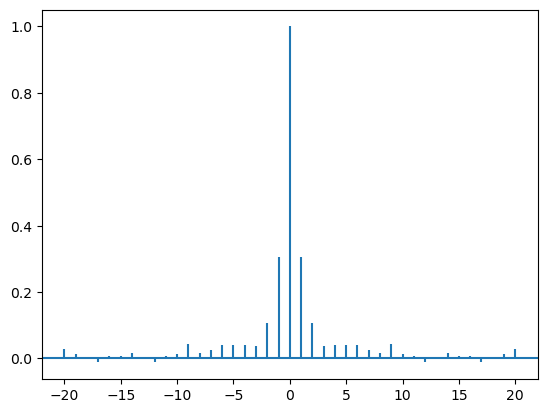

In [58]:
plt.acorr(x, maxlags=20)
plt.show()

In [5]:
ci = 0.1 * np.ones((200, 200), dtype=np.float32)
cs = 0.1 * np.ones((200, 200), dtype=np.float32)
cp = 0.1 * np.ones((200, 200), dtype=np.float32)

cjsr = 750.0 * np.ones((200,200), dtype=np.float32)
cnsr = 750.0 * np.ones((200,200), dtype=np.float32)

CaTi = 20.0 * np.ones((200,200), dtype=np.float32)
CaTs = 20.0 * np.ones((200,200), dtype=np.float32)

params = RestrepoParams()

In [6]:
RyR = RyR_stationary(cp, params)

In [7]:
LCC = LCC_stationary(cp, 0.1, params)

In [8]:
cru_obj = CRUs(params, RyR, LCC, ci, cnsr, cjsr, cs, cp, CaTi, CaTs)

In [9]:
cru_obj.forward(0.1, 100.0, 1e-2, nstep=1000, _tpb2d=32, _tpb1d=512)

/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 2 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))
/home/luke/anaconda3/lib/python3.11/site-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 49 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


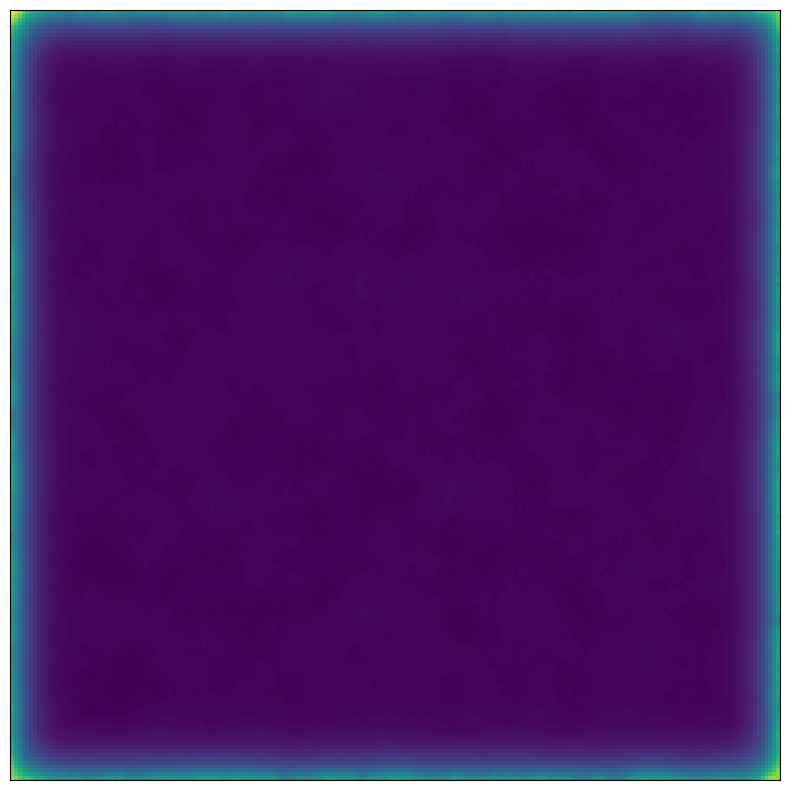

In [24]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(cru_obj.ci, aspect='equal')
ax.set_yticks([])
ax.set_xticks([])
plt.show()

In [110]:
from scipy.fft import fft2, ifft2, fftfreq, fftshift, ifftshift

In [134]:
modes = ifftshift(fft2(fftshift(cru_obj.RyR[..., 1:3].sum(axis=-1) - cru_obj.RyR[..., 1:3].sum(axis=-1).mean()), norm="ortho"))

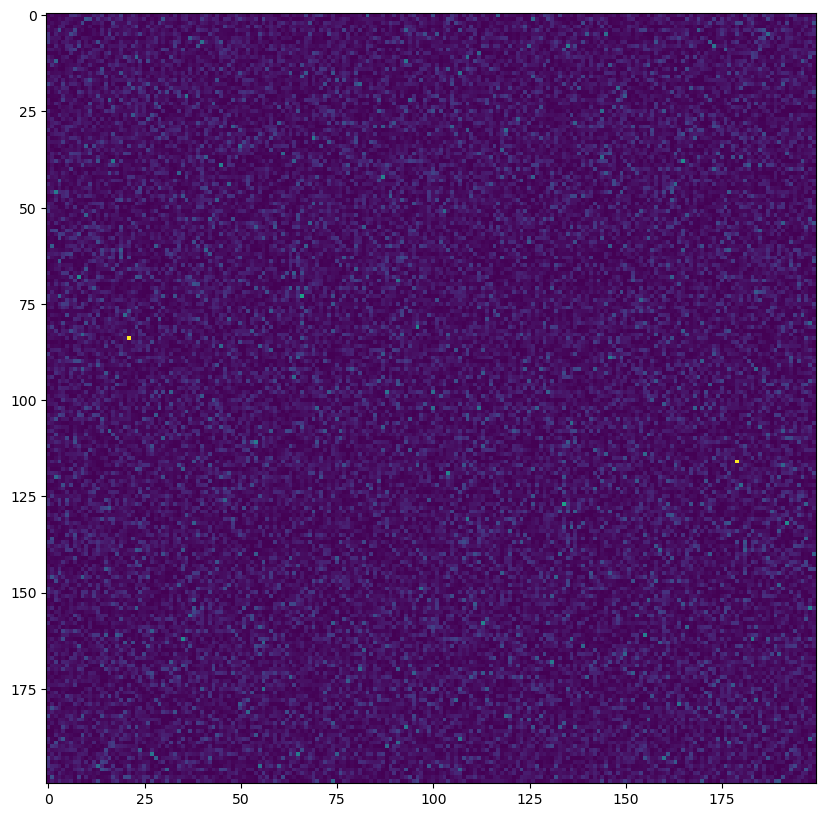

In [135]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(np.abs(modes)**2)
plt.show()

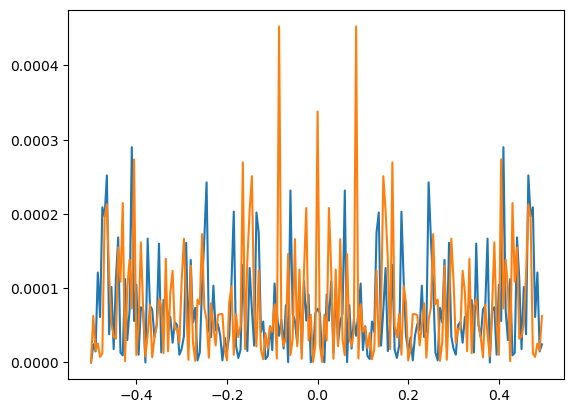

In [136]:
freqs = fftshift(fftfreq(modes[0,:].shape[0]))
plt.plot(freqs, np.abs(modes)[:, 0]**2)
plt.plot(freqs, np.abs(modes)[0, :]**2)
plt.show()

In [137]:
autocor = ifftshift(ifft2(fftshift(np.abs(modes)**2), norm="ortho"))

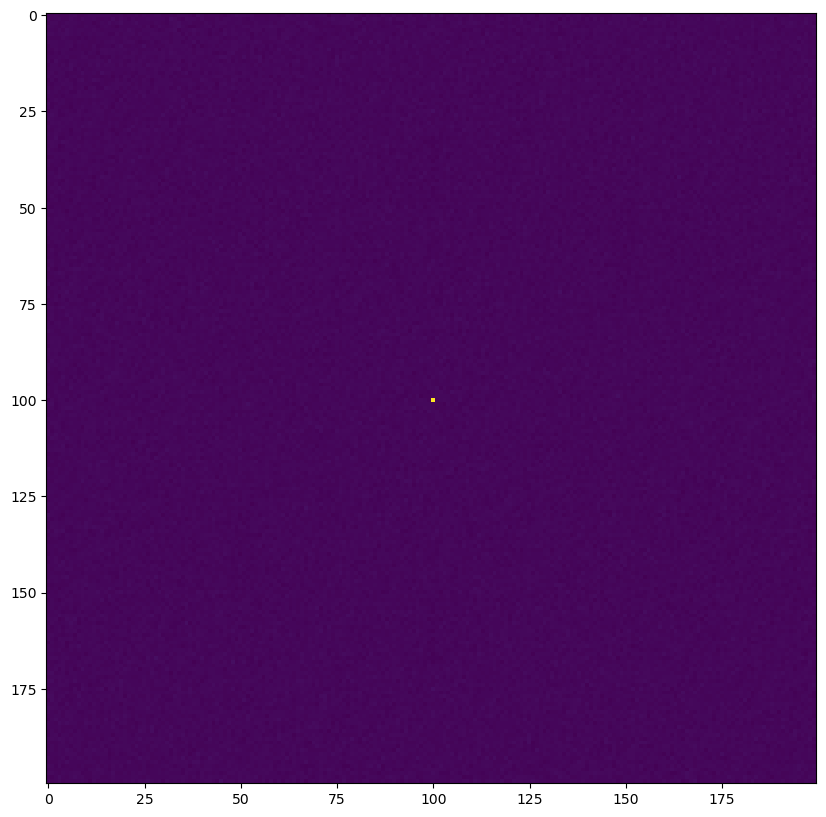

In [138]:
fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(autocor.real)
plt.show()

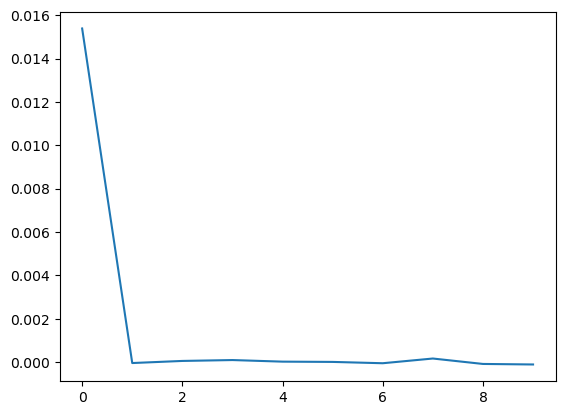

In [140]:
plt.plot(autocor[autocor.shape[0]//2, (autocor.shape[0]//2):(autocor.shape[0]//2+10)].real)
plt.show()

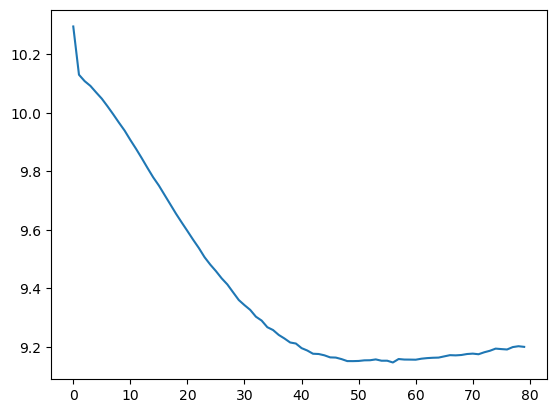

In [126]:
plt.plot(np.log(np.abs(autocor[autocor.shape[0]//2, (autocor.shape[0]//2):(autocor.shape[0]//2+80)].real)))
plt.show()

In [12]:
dW_h = cru_obj.dW.copy_to_host()
rates_h = cru_obj.RyR_rates.copy_to_host()

RyR_test = test_RyR_cpu(RyR, rates_h, dW_h, 5e-3)

In [13]:
np.allclose(cru_obj.RyR, RyR_test)

True